# Clasificación de textos literarios: Poe, Lovecraft y Shelley

**Dataset:** *Spooky Author Identification* — fragmentos de tres escritores de terror/gótico del siglo XIX-XX.

| Código | Autor | Época | Estilo |
|--------|-------|-------|--------|
| **EAP** | Edgar Allan Poe | 1809–1849 | Terror psicológico, prosa densa |
| **HPL** | H.P. Lovecraft | 1890–1937 | Horror cósmico, vocabulario arcaico |
| **MWS** | Mary W. Shelley | 1797–1851 | Ciencia ficción gótica, sentimentalismo |

## Estrategia: tres representaciones de texto, mismos clasificadores

```
Texto  ──▶  TF-IDF            ──▶  ┐
       ──▶  Word2Vec (avg)    ──▶  ├── Regresión Logística / SVM  ──▶  Autor
       ──▶  Sentence-BERT     ──▶  ┘
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from collections import Counter
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity

from gensim.models import Word2Vec, FastText
from sentence_transformers import SentenceTransformer

plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['font.size'] = 12

# Colores fijos por autor
COLORES = {'EAP': '#e74c3c', 'HPL': '#3498db', 'MWS': '#2ecc71'}
NOMBRES = {'EAP': 'Edgar Allan Poe', 'HPL': 'H.P. Lovecraft', 'MWS': 'Mary W. Shelley'}
print('Entorno listo.')

Entorno listo.


## 0. Análisis exploratorio (EDA)

In [2]:
train_df = pd.read_csv('Data/train.csv')
test_df  = pd.read_csv('Data/test.csv')

train_df['n_words'] = train_df['text'].str.split().str.len()
train_df['n_chars'] = train_df['text'].str.len()

print(f'Train: {len(train_df):,} muestras | Test: {len(test_df):,} muestras')
print(f'Clases: {train_df["author"].value_counts().to_dict()}')
print(f'Longitud media: {train_df["n_words"].mean():.1f} palabras')
train_df.head(3)

Train: 19,579 muestras | Test: 8,392 muestras
Clases: {'EAP': 7900, 'MWS': 6044, 'HPL': 5635}
Longitud media: 26.7 palabras


,id,text,author,n_words,n_chars
0,id26305,"This process, however, afforded me no means of...",EAP,41,231
1,id17569,It never once occurred to me that the fumbling...,HPL,14,71
2,id11008,"In his left hand was a gold snuff box, from wh...",EAP,36,200


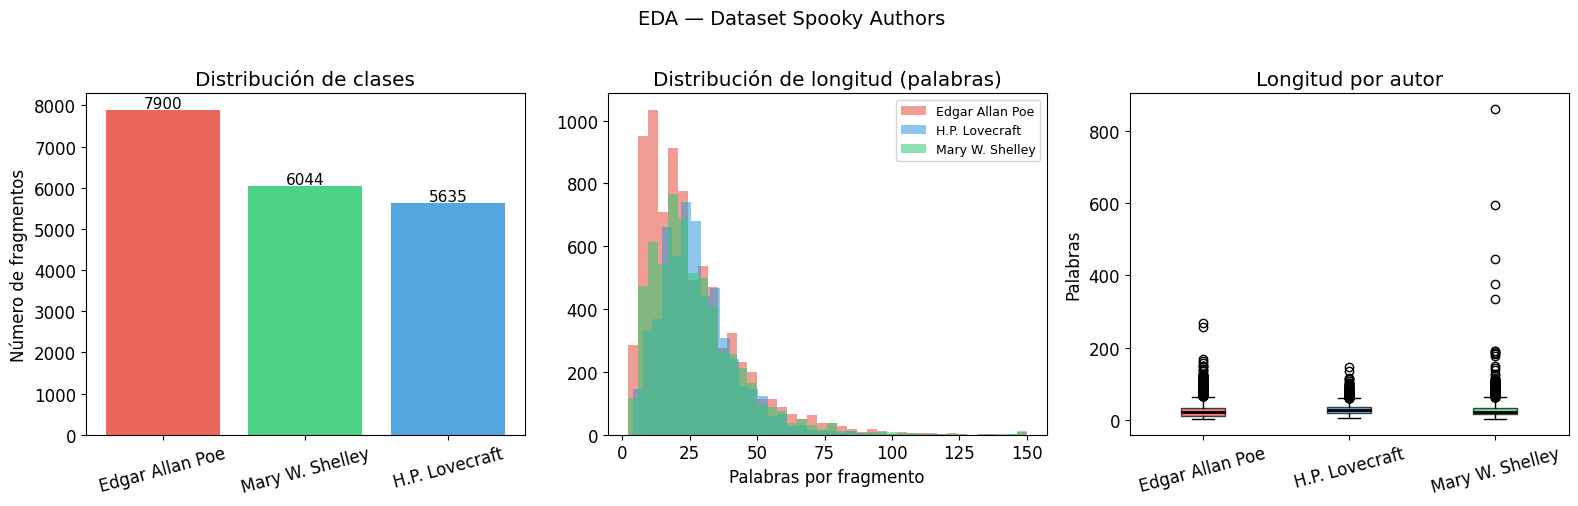

         count  mean   std  min   25%   50%   75%    max
author                                                  
EAP     7900.0  25.4  18.6  2.0  12.0  21.0  33.0  267.0
HPL     5635.0  27.8  14.1  4.0  18.0  26.0  35.0  147.0
MWS     6044.0  27.4  23.1  2.0  15.0  23.0  34.0  861.0


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distribución de clases
counts = train_df['author'].value_counts()
axes[0].bar([NOMBRES[a] for a in counts.index], counts.values,
            color=[COLORES[a] for a in counts.index], alpha=0.85)
axes[0].set_title('Distribución de clases')
axes[0].set_ylabel('Número de fragmentos')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontsize=11)

# Longitud de textos (palabras)
for autor, grp in train_df.groupby('author'):
    axes[1].hist(grp['n_words'].clip(upper=150), bins=40,
                 alpha=0.55, color=COLORES[autor], label=NOMBRES[autor])
axes[1].set_title('Distribución de longitud (palabras)')
axes[1].set_xlabel('Palabras por fragmento')
axes[1].legend(fontsize=9)

# Box plot de longitud por autor
data_box = [train_df[train_df['author']==a]['n_words'].values for a in ['EAP','HPL','MWS']]
bp = axes[2].boxplot(data_box, labels=[NOMBRES[a] for a in ['EAP','HPL','MWS']],
                     patch_artist=True, medianprops=dict(color='black', lw=2))
for patch, autor in zip(bp['boxes'], ['EAP','HPL','MWS']):
    patch.set_facecolor(COLORES[autor])
    patch.set_alpha(0.7)
axes[2].set_title('Longitud por autor')
axes[2].set_ylabel('Palabras')
axes[2].tick_params(axis='x', rotation=15)

plt.suptitle('EDA — Dataset Spooky Authors', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(train_df.groupby('author')['n_words'].describe().round(1).to_string())

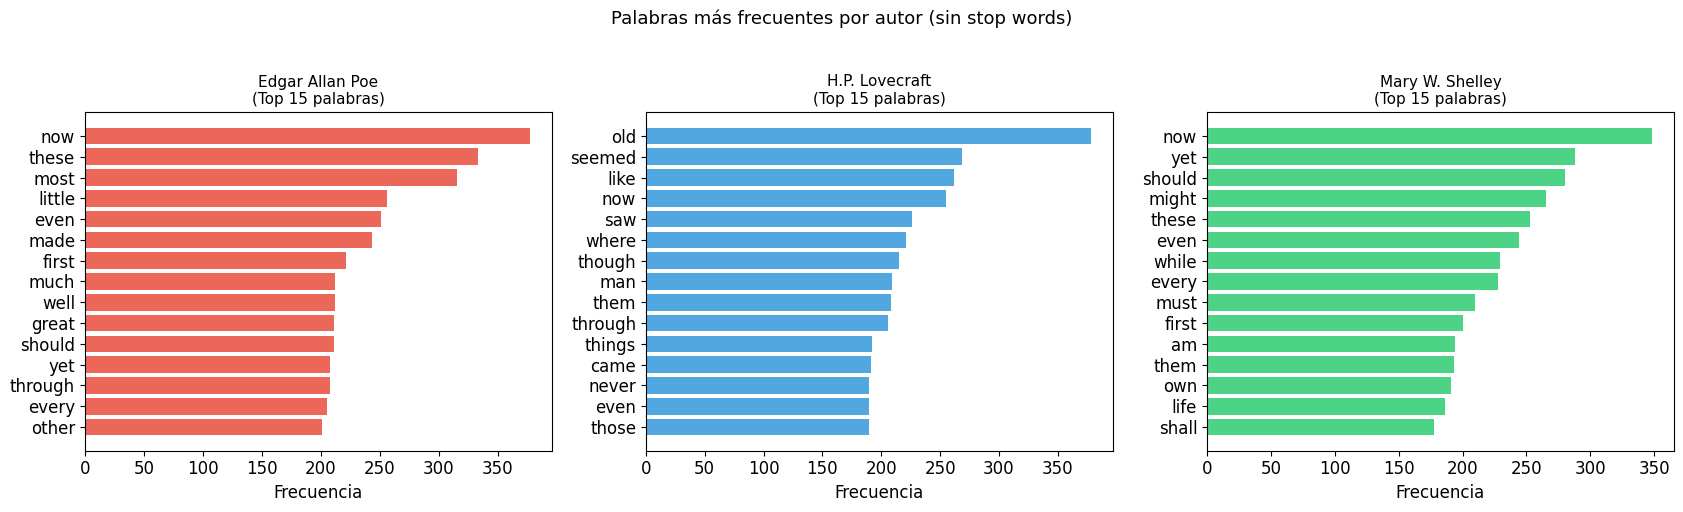

In [4]:
# Palabras más discriminativas por autor (excluyendo stop words comunes)
STOP = {'the','a','an','and','or','but','in','on','at','to','for','of','with',
        'is','was','it','he','she','i','my','his','her','that','this','as',
        'had','have','been','be','by','not','from','are','were','which','who',
        'its','their','they','we','you','your','our','me','him','us','what',
        'all','no','so','if','then','than','into','upon','there','has','would',
        'could','said','one','when','will','more','very','up','out','about',
        'after','before','could','any','some','do','did','over','only','such'}

def top_words(df, autor, n=15):
    words = ' '.join(df[df['author']==autor]['text']).lower().split()
    return Counter(w for w in words if w.isalpha() and w not in STOP).most_common(n)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, autor in zip(axes, ['EAP', 'HPL', 'MWS']):
    palabras, freqs = zip(*top_words(train_df, autor))
    ax.barh(list(reversed(palabras)), list(reversed(freqs)),
            color=COLORES[autor], alpha=0.85)
    ax.set_title(f'{NOMBRES[autor]}\n(Top 15 palabras)', fontsize=11)
    ax.set_xlabel('Frecuencia')

plt.suptitle('Palabras más frecuentes por autor (sin stop words)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [5]:
# Partition: 80% train / 20% validación (estratificada)
X_train, X_val, y_train, y_val = train_test_split(
    train_df['text'].values,
    train_df['author'].values,
    test_size=0.20,
    random_state=42,
    stratify=train_df['author'].values
)

print(f'Train: {len(X_train):,} muestras | Val: {len(X_val):,} muestras')
print('Distribución train:', Counter(y_train))
print('Distribución val:  ', Counter(y_val))

# Diccionario para acumular resultados
resultados = {}

Train: 15,663 muestras | Val: 3,916 muestras
Distribución train: Counter({'EAP': 6320, 'MWS': 4835, 'HPL': 4508})
Distribución val:   Counter({'EAP': 1580, 'MWS': 1209, 'HPL': 1127})


## 1. TF-IDF

**TF-IDF** (Term Frequency – Inverse Document Frequency) representa cada texto como un vector no denso donde cada dimensión es una palabra del vocabulario, ponderada por:

$$\text{tfidf}(t, d) = \underbrace{\frac{|\{t \in d\}|}{|d|}}_{\text{TF: frecuencia local}} \times \underbrace{\log\frac{N}{|\{d: t \in d\}|}}_{\text{IDF: rareza global}}$$

Palabras frecuentes en un documento pero raras en el corpus → peso alto.  
Palabras comunes en todos los documentos (stop words) → peso bajo.

In [6]:
t0 = time.time()

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),   # unigramas + bigramas
    max_features=50_000,
    sublinear_tf=True,    # log(1 + tf) en lugar de tf
    min_df=3,
    strip_accents='unicode',
    analyzer='word',
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
t_tfidf_vec = time.time() - t0

print(f'Vocabulario TF-IDF: {len(tfidf.vocabulary_):,} n-gramas')
print(f'Matriz train: {X_train_tfidf.shape}  (esparsa: {X_train_tfidf.nnz / X_train_tfidf.shape[0]:.1f} valores no-cero por muestra)')
print(f'Tiempo vectorización: {t_tfidf_vec:.2f}s')

Vocabulario TF-IDF: 31,965 n-gramas
Matriz train: (15663, 31965)  (esparsa: 33.2 valores no-cero por muestra)
Tiempo vectorización: 1.36s


In [7]:
def evaluar(nombre, clf, X_tr, X_vl, y_tr, y_vl, tiempo_vec=0):
    t0 = time.time()
    clf.fit(X_tr, y_tr)
    t_train = time.time() - t0
    t0 = time.time()
    preds = clf.predict(X_vl)
    t_inf = time.time() - t0
    acc = accuracy_score(y_vl, preds)
    f1  = f1_score(y_vl, preds, average='macro')
    print(f'{nombre:<40} Acc={acc:.4f}  F1-macro={f1:.4f}  '
          f'(vec={tiempo_vec:.1f}s, train={t_train:.1f}s, inf={t_inf*1000:.0f}ms)')
    return {'acc': acc, 'f1': f1, 'preds': preds,
            't_vec': tiempo_vec, 't_train': t_train, 't_inf': t_inf}

print('=== TF-IDF + clasificadores ===')
res_tfidf_lr  = evaluar('TF-IDF + LogReg (C=5)',
    LogisticRegression(C=5, max_iter=1000, solver='lbfgs', multi_class='multinomial'),
    X_train_tfidf, X_val_tfidf, y_train, y_val, t_tfidf_vec)

res_tfidf_svm = evaluar('TF-IDF + LinearSVC (C=1)',
    LinearSVC(C=1, max_iter=2000),
    X_train_tfidf, X_val_tfidf, y_train, y_val, t_tfidf_vec)

resultados['TF-IDF + LogReg']    = res_tfidf_lr
resultados['TF-IDF + LinearSVC'] = res_tfidf_svm

=== TF-IDF + clasificadores ===
TF-IDF + LogReg (C=5)                    Acc=0.8399  F1-macro=0.8382  (vec=1.4s, train=1.6s, inf=1ms)
TF-IDF + LinearSVC (C=1)                 Acc=0.8430  F1-macro=0.8417  (vec=1.4s, train=0.2s, inf=1ms)


In [8]:
# Reporte detallado
print(classification_report(y_val, res_tfidf_lr['preds'],
      target_names=[NOMBRES[a] for a in ['EAP', 'HPL', 'MWS']]))

                 precision    recall  f1-score   support

Edgar Allan Poe       0.83      0.87      0.85      1580
 H.P. Lovecraft       0.84      0.81      0.82      1127
Mary W. Shelley       0.85      0.83      0.84      1209

       accuracy                           0.84      3916
      macro avg       0.84      0.84      0.84      3916
   weighted avg       0.84      0.84      0.84      3916



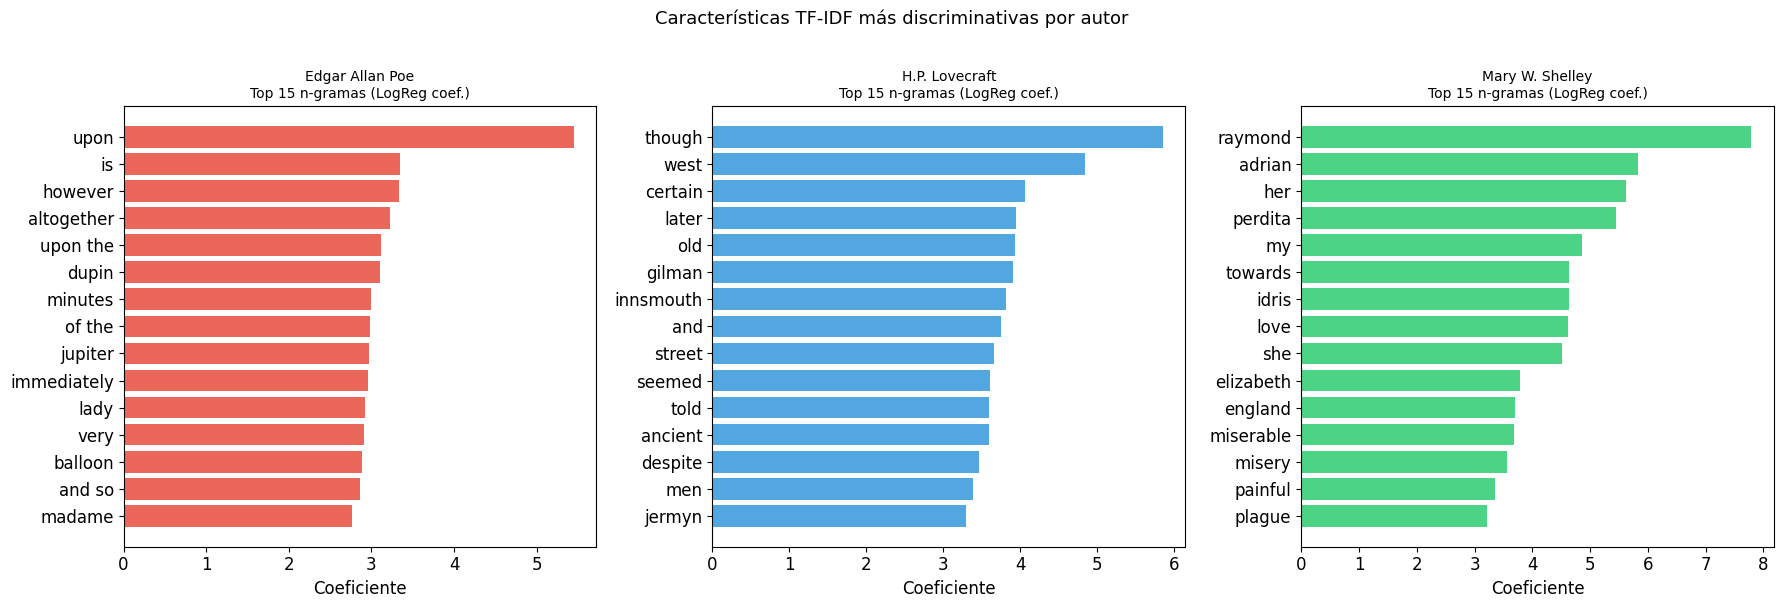

In [9]:
# Palabras con mayor peso TF-IDF por clase (coeficientes del modelo LogReg)
lr_modelo = LogisticRegression(C=5, max_iter=1000, solver='lbfgs', multi_class='multinomial')
lr_modelo.fit(X_train_tfidf, y_train)

feature_names = np.array(tfidf.get_feature_names_out())
autores_orden = lr_modelo.classes_
top_n = 15

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (i, autor) in zip(axes, enumerate(autores_orden)):
    coefs = lr_modelo.coef_[i]
    top_idx = np.argsort(coefs)[-top_n:]
    ax.barh(feature_names[top_idx], coefs[top_idx],
            color=COLORES[autor], alpha=0.85)
    ax.set_title(f'{NOMBRES[autor]}\nTop {top_n} n-gramas (LogReg coef.)', fontsize=10)
    ax.set_xlabel('Coeficiente')

plt.suptitle('Características TF-IDF más discriminativas por autor', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 2. Word2Vec / FastText — sentence embeddings por promedio

Entrenamos un modelo Word2Vec/FastText sobre el corpus y representamos cada texto como el **promedio** de los vectores de sus palabras.

```
"the raven flew over" → [vec(the) + vec(raven) + vec(flew) + vec(over)] / 4
```

**Ventaja sobre TF-IDF:** captura semántica distribucional.  
**Limitación:** ignora el orden de las palabras.

In [10]:
# Tokenizar todo el corpus (train) para entrenar los modelos
all_sentences = [text.lower().split() for text in train_df['text']]

t0 = time.time()
w2v = Word2Vec(
    sentences=all_sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1,
    epochs=10,
    seed=42
)
t_w2v = time.time() - t0

t0 = time.time()
ft = FastText(
    sentences=all_sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1,
    min_n=3, max_n=6,
    epochs=10,
    seed=42
)
t_ft = time.time() - t0

print(f'Word2Vec: {len(w2v.wv):,} palabras, entrenado en {t_w2v:.1f}s')
print(f'FastText: {len(ft.wv):,} palabras, entrenado en {t_ft:.1f}s')

Word2Vec: 22,482 palabras, entrenado en 6.6s
FastText: 22,482 palabras, entrenado en 15.5s


In [11]:
def text_to_vec(text, model_wv, vector_size=100):
    words = text.lower().split()
    vecs  = [model_wv[w] for w in words if w in model_wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(vector_size)

def corpus_to_matrix(texts, model_wv, vector_size=100):
    return np.array([text_to_vec(t, model_wv, vector_size) for t in texts])

t0 = time.time()
X_train_w2v = corpus_to_matrix(X_train, w2v.wv)
X_val_w2v   = corpus_to_matrix(X_val,   w2v.wv)
t_w2v_vec   = time.time() - t0

t0 = time.time()
X_train_ft  = corpus_to_matrix(X_train, ft.wv)
X_val_ft    = corpus_to_matrix(X_val,   ft.wv)
t_ft_vec    = time.time() - t0

print(f'Matriz W2V train: {X_train_w2v.shape}  ({t_w2v_vec:.2f}s)')
print(f'Matriz  FT train: {X_train_ft.shape}   ({t_ft_vec:.2f}s)')

Matriz W2V train: (15663, 100)  (1.19s)
Matriz  FT train: (15663, 100)   (2.05s)


In [12]:
print('=== Word2Vec avg + clasificadores ===')
res_w2v_lr  = evaluar('Word2Vec avg + LogReg',
    LogisticRegression(C=5, max_iter=1000, solver='lbfgs', multi_class='multinomial'),
    X_train_w2v, X_val_w2v, y_train, y_val, t_w2v + t_w2v_vec)

res_w2v_svm = evaluar('Word2Vec avg + LinearSVC',
    LinearSVC(C=1, max_iter=2000),
    X_train_w2v, X_val_w2v, y_train, y_val, t_w2v + t_w2v_vec)

print()
print('=== FastText avg + clasificadores ===')
res_ft_lr   = evaluar('FastText avg + LogReg',
    LogisticRegression(C=5, max_iter=1000, solver='lbfgs', multi_class='multinomial'),
    X_train_ft, X_val_ft, y_train, y_val, t_ft + t_ft_vec)

res_ft_svm  = evaluar('FastText avg + LinearSVC',
    LinearSVC(C=1, max_iter=2000),
    X_train_ft, X_val_ft, y_train, y_val, t_ft + t_ft_vec)

resultados['W2V + LogReg']  = res_w2v_lr
resultados['W2V + SVM']     = res_w2v_svm
resultados['FT + LogReg']   = res_ft_lr
resultados['FT + SVM']      = res_ft_svm

=== Word2Vec avg + clasificadores ===
Word2Vec avg + LogReg                    Acc=0.7464  F1-macro=0.7450  (vec=7.8s, train=2.1s, inf=1ms)
Word2Vec avg + LinearSVC                 Acc=0.7446  F1-macro=0.7429  (vec=7.8s, train=1.5s, inf=1ms)

=== FastText avg + clasificadores ===
FastText avg + LogReg                    Acc=0.7569  F1-macro=0.7559  (vec=17.5s, train=4.3s, inf=2ms)
FastText avg + LinearSVC                 Acc=0.7549  F1-macro=0.7536  (vec=17.5s, train=1.6s, inf=2ms)


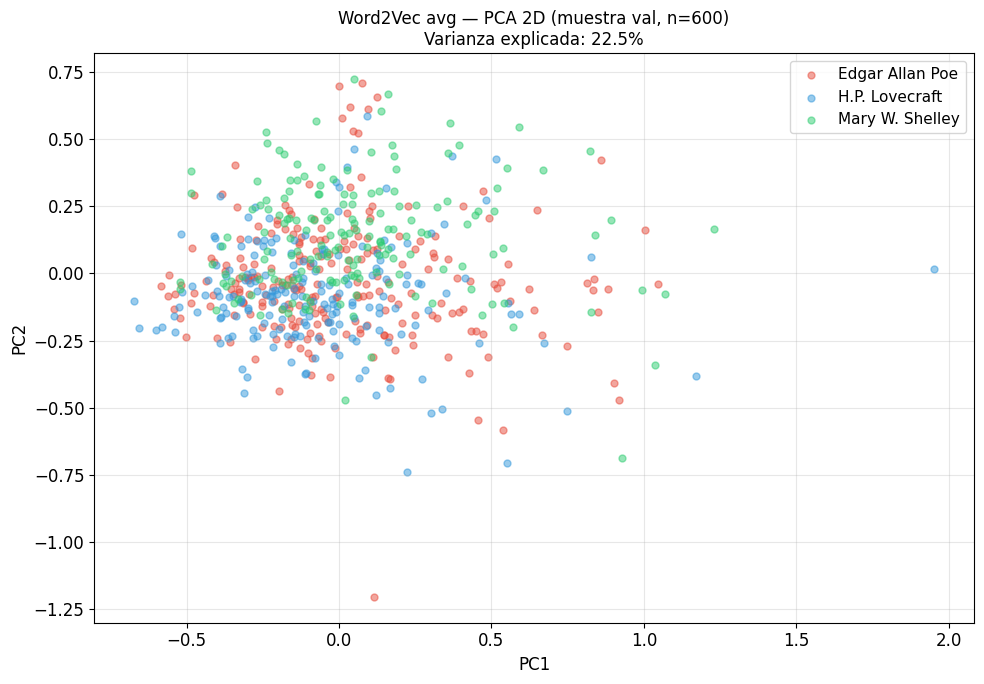

In [13]:
# Visualizar embeddings Word2Vec en 2D (PCA)
# Tomar una muestra para que sea rápido
idx_sample = np.random.RandomState(42).choice(len(X_val), 600, replace=False)
X_sample   = X_val_w2v[idx_sample]
y_sample   = y_val[idx_sample]

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_sample)

fig, ax = plt.subplots(figsize=(10, 7))
for autor in ['EAP', 'HPL', 'MWS']:
    mask = y_sample == autor
    ax.scatter(coords[mask, 0], coords[mask, 1], c=COLORES[autor],
               alpha=0.5, s=25, label=NOMBRES[autor])

ax.legend(fontsize=11)
ax.set_title(f'Word2Vec avg — PCA 2D (muestra val, n=600)\n'
             f'Varianza explicada: {pca.explained_variance_ratio_.sum():.1%}', fontsize=12)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Sentence-BERT — embeddings contextuales

Usamos `paraphrase-multilingual-MiniLM-L12-v2` (ya en caché local) para obtener un vector de **384 dimensiones** por frase que captura contexto y orden.

> Los embeddings se calculan una sola vez (feature extraction). No hay fine-tuning.

In [14]:
sbert = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
print(f'Modelo: paraphrase-multilingual-MiniLM-L12-v2')
print(f'Dimensión de embeddings: {sbert.get_sentence_embedding_dimension()}')
print()
print('Codificando train (~15k muestras, puede tardar 2-4 min en CPU)...')

t0 = time.time()
X_train_sbert = sbert.encode(X_train.tolist(), batch_size=64,
                              show_progress_bar=True, convert_to_numpy=True)
t_sbert_train = time.time() - t0

t0 = time.time()
X_val_sbert   = sbert.encode(X_val.tolist(),   batch_size=64,
                              show_progress_bar=True, convert_to_numpy=True)
t_sbert_val   = time.time() - t0
t_sbert_vec   = t_sbert_train + t_sbert_val

print(f'\nMatriz SBERT train: {X_train_sbert.shape}  ({t_sbert_train:.1f}s)')
print(f'Matriz SBERT val:   {X_val_sbert.shape}   ({t_sbert_val:.1f}s)')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6528.13it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo: paraphrase-multilingual-MiniLM-L12-v2
Dimensión de embeddings: 384

Codificando train (~15k muestras, puede tardar 2-4 min en CPU)...


Batches: 100%|██████████| 62/62 [00:46<00:00,  1.32it/s]


Matriz SBERT train: (15663, 384)  (185.3s)
Matriz SBERT val:   (3916, 384)   (46.9s)


In [15]:
print('=== Sentence-BERT + clasificadores ===')
res_sbert_lr  = evaluar('Sentence-BERT + LogReg',
    LogisticRegression(C=5, max_iter=1000, solver='lbfgs', multi_class='multinomial'),
    X_train_sbert, X_val_sbert, y_train, y_val, t_sbert_vec)

res_sbert_svm = evaluar('Sentence-BERT + LinearSVC',
    LinearSVC(C=1, max_iter=2000),
    X_train_sbert, X_val_sbert, y_train, y_val, t_sbert_vec)

resultados['SBERT + LogReg'] = res_sbert_lr
resultados['SBERT + SVM']    = res_sbert_svm

print()
print(classification_report(y_val, res_sbert_lr['preds'],
      target_names=[NOMBRES[a] for a in ['EAP', 'HPL', 'MWS']]))

=== Sentence-BERT + clasificadores ===
Sentence-BERT + LogReg                   Acc=0.7508  F1-macro=0.7497  (vec=232.1s, train=5.3s, inf=7ms)
Sentence-BERT + LinearSVC                Acc=0.7518  F1-macro=0.7505  (vec=232.1s, train=9.0s, inf=6ms)

                 precision    recall  f1-score   support

Edgar Allan Poe       0.76      0.76      0.76      1580
 H.P. Lovecraft       0.73      0.73      0.73      1127
Mary W. Shelley       0.76      0.76      0.76      1209

       accuracy                           0.75      3916
      macro avg       0.75      0.75      0.75      3916
   weighted avg       0.75      0.75      0.75      3916



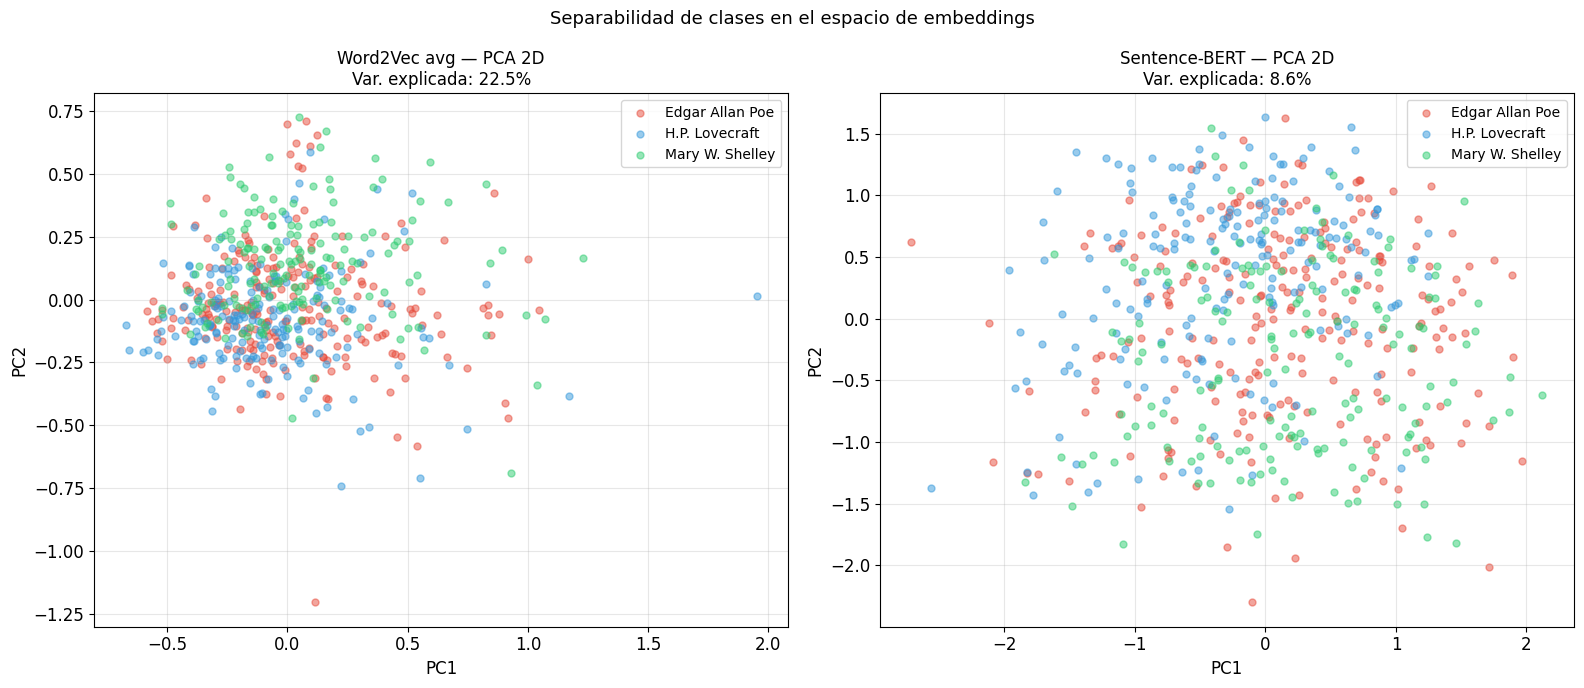

In [16]:
# Visualizar embeddings SBERT en 2D (PCA)
X_sbert_sample = X_val_sbert[idx_sample]
pca_s = PCA(n_components=2, random_state=42)
coords_s = pca_s.fit_transform(X_sbert_sample)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
for ax, coords_plot, titulo, var in [
    (ax1, coords,   'Word2Vec avg', pca.explained_variance_ratio_.sum()),
    (ax2, coords_s, 'Sentence-BERT', pca_s.explained_variance_ratio_.sum())
]:
    for autor in ['EAP', 'HPL', 'MWS']:
        mask = y_sample == autor
        ax.scatter(coords_plot[mask, 0], coords_plot[mask, 1],
                   c=COLORES[autor], alpha=0.5, s=25, label=NOMBRES[autor])
    ax.legend(fontsize=10)
    ax.set_title(f'{titulo} — PCA 2D\nVar. explicada: {var:.1%}', fontsize=12)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.grid(True, alpha=0.3)

plt.suptitle('Separabilidad de clases en el espacio de embeddings', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Comparación final

In [17]:
# Tabla comparativa
df_res = pd.DataFrame([
    {'Método': nombre, 'Accuracy': v['acc'], 'F1-macro': v['f1'],
     't_total(s)': round(v['t_vec'] + v['t_train'], 1)}
    for nombre, v in resultados.items()
]).sort_values('F1-macro', ascending=False).reset_index(drop=True)

df_res['Accuracy'] = df_res['Accuracy'].map('{:.4f}'.format)
df_res['F1-macro'] = df_res['F1-macro'].map('{:.4f}'.format)
print(df_res.to_string(index=False))

            Método Accuracy F1-macro  t_total(s)
TF-IDF + LinearSVC   0.8430   0.8417         1.6
   TF-IDF + LogReg   0.8399   0.8382         2.9
       FT + LogReg   0.7569   0.7559        21.8
          FT + SVM   0.7549   0.7536        19.2
       SBERT + SVM   0.7518   0.7505       241.2
    SBERT + LogReg   0.7508   0.7497       237.4
      W2V + LogReg   0.7464   0.7450         9.9
         W2V + SVM   0.7446   0.7429         9.3


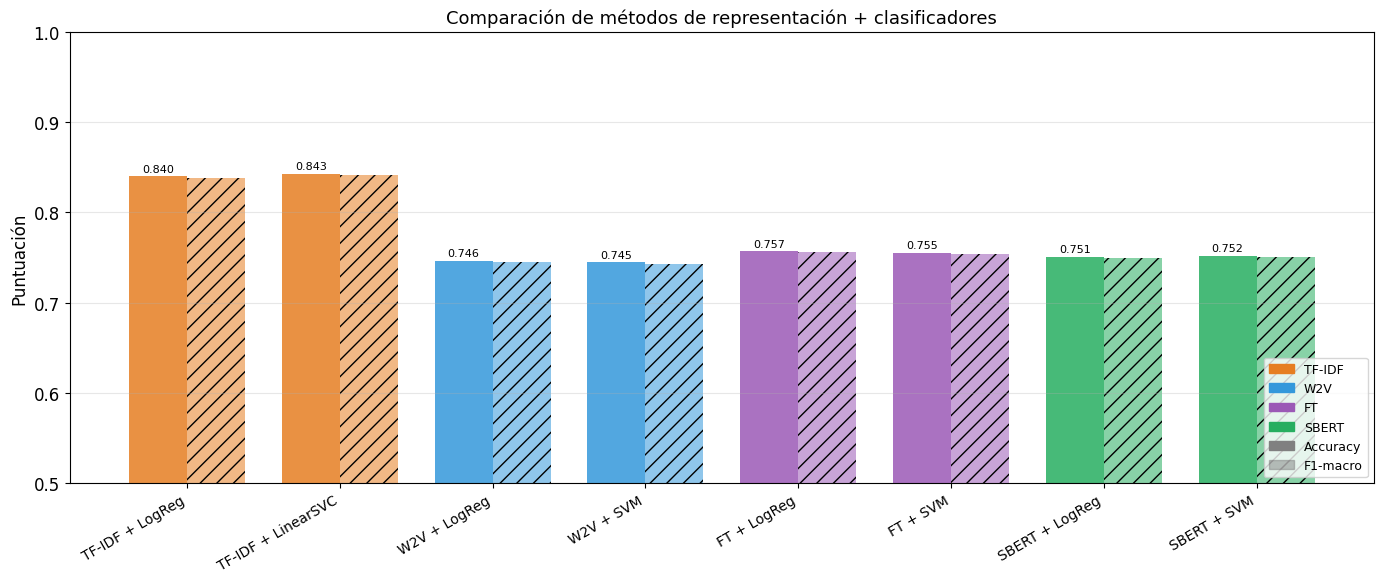

In [18]:
# Gráfico de barras comparativo
nombres = list(resultados.keys())
accs  = [resultados[n]['acc'] for n in nombres]
f1s   = [resultados[n]['f1']  for n in nombres]

x = np.arange(len(nombres))
w = 0.38

grupos_colores = {
    'TF-IDF': '#e67e22', 'W2V': '#3498db', 'FT': '#9b59b6', 'SBERT': '#27ae60'
}
def color_metodo(n):
    if 'TF-IDF' in n: return grupos_colores['TF-IDF']
    if 'W2V'   in n: return grupos_colores['W2V']
    if 'FT'    in n: return grupos_colores['FT']
    return grupos_colores['SBERT']

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - w/2, accs, w, label='Accuracy', alpha=0.85,
               color=[color_metodo(n) for n in nombres])
bars2 = ax.bar(x + w/2, f1s,  w, label='F1-macro', alpha=0.55,
               color=[color_metodo(n) for n in nombres], hatch='//')

ax.set_xticks(x)
ax.set_xticklabels(nombres, rotation=30, ha='right', fontsize=10)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Puntuación')
ax.set_title('Comparación de métodos de representación + clasificadores', fontsize=13)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Anotaciones de valor
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

# Leyenda de grupos
leyenda_grupos = [mpatches.Patch(color=c, label=g) for g, c in grupos_colores.items()]
ax.legend(handles=leyenda_grupos + [mpatches.Patch(color='gray', label='Accuracy'),
           mpatches.Patch(color='gray', alpha=0.5, hatch='//', label='F1-macro')],
          loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

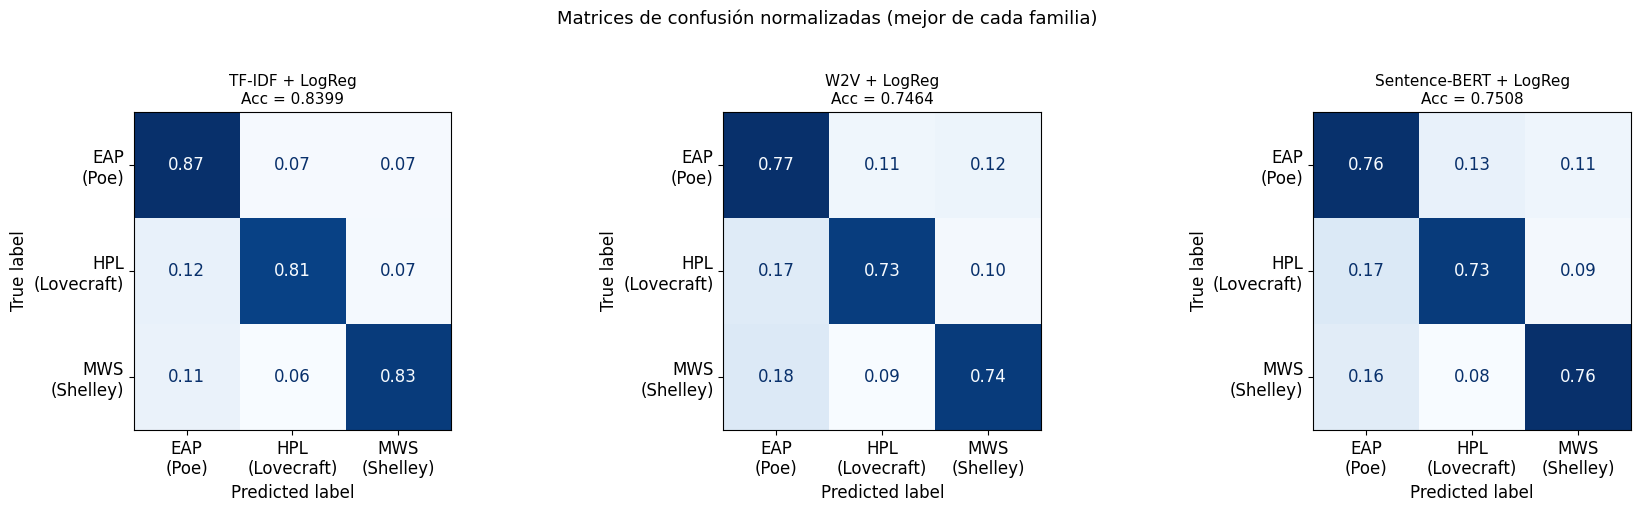

In [19]:
# Matrices de confusión para los 3 mejores (uno por familia)
mejores = [
    ('TF-IDF + LogReg',    res_tfidf_lr['preds']),
    ('W2V + LogReg',       res_w2v_lr['preds']),
    ('Sentence-BERT + LogReg', res_sbert_lr['preds']),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (nombre, preds) in zip(axes, mejores):
    cm = confusion_matrix(y_val, preds, labels=['EAP', 'HPL', 'MWS'], normalize='true')
    disp = ConfusionMatrixDisplay(cm, display_labels=['EAP\n(Poe)', 'HPL\n(Lovecraft)', 'MWS\n(Shelley)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='.2f')
    acc = accuracy_score(y_val, preds)
    ax.set_title(f'{nombre}\nAcc = {acc:.4f}', fontsize=11)

plt.suptitle('Matrices de confusión normalizadas (mejor de cada familia)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 5. Análisis de errores

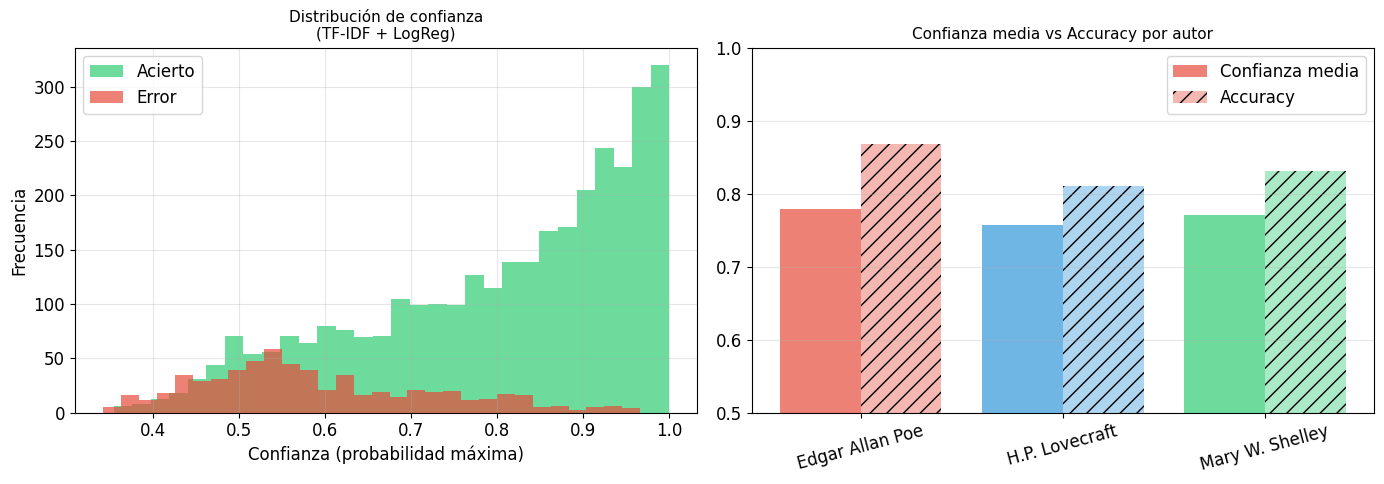

In [20]:
# Analizar los errores del mejor modelo (TF-IDF + LogReg)
# Obtener probabilidades
lr_best = LogisticRegression(C=5, max_iter=1000, solver='lbfgs', multi_class='multinomial')
lr_best.fit(X_train_tfidf, y_train)
probs = lr_best.predict_proba(X_val_tfidf)
preds_best = lr_best.predict(X_val_tfidf)
clases = lr_best.classes_

# Confianza del modelo
confianza = probs.max(axis=1)
aciertos  = preds_best == y_val

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de confianza: aciertos vs errores
axes[0].hist(confianza[aciertos],  bins=30, alpha=0.7, color='#2ecc71', label='Acierto')
axes[0].hist(confianza[~aciertos], bins=30, alpha=0.7, color='#e74c3c', label='Error')
axes[0].set_xlabel('Confianza (probabilidad máxima)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de confianza\n(TF-IDF + LogReg)', fontsize=11)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Confianza media por autor
conf_por_autor = {a: confianza[y_val == a].mean() for a in ['EAP', 'HPL', 'MWS']}
acc_por_autor  = {a: aciertos[y_val == a].mean()  for a in ['EAP', 'HPL', 'MWS']}
x_pos = np.arange(3)
etiq  = [NOMBRES[a] for a in ['EAP','HPL','MWS']]
axes[1].bar(x_pos - 0.2, [conf_por_autor[a] for a in ['EAP','HPL','MWS']], 0.4,
            label='Confianza media', color=[COLORES[a] for a in ['EAP','HPL','MWS']], alpha=0.7)
axes[1].bar(x_pos + 0.2, [acc_por_autor[a]  for a in ['EAP','HPL','MWS']], 0.4,
            label='Accuracy',       color=[COLORES[a] for a in ['EAP','HPL','MWS']], alpha=0.4, hatch='//')
axes[1].set_xticks(x_pos); axes[1].set_xticklabels(etiq, rotation=15)
axes[1].set_ylim(0.5, 1.0); axes[1].legend()
axes[1].set_title('Confianza media vs Accuracy por autor', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
# Ejemplos de errores con alta confianza (el modelo se equivoca pero está seguro)
errores_conf = np.argsort(confianza[~aciertos])[::-1][:5]
idx_errores  = np.where(~aciertos)[0][errores_conf]

print('Errores con mayor confianza (el modelo se equivocó pero estaba "seguro"):')
print('=' * 90)
for idx in idx_errores:
    pred_autor  = preds_best[idx]
    real_autor  = y_val[idx]
    prob_vector = {clases[i]: f'{probs[idx][i]:.3f}' for i in range(3)}
    texto       = X_val[idx][:120] + '...' if len(X_val[idx]) > 120 else X_val[idx]
    print(f'  Real: {NOMBRES[real_autor]:<25} Predicho: {NOMBRES[pred_autor]}')
    print(f'  Probs: {prob_vector}')
    print(f'  Texto: "{texto}"')
    print()

Errores con mayor confianza (el modelo se equivocó pero estaba "seguro"):
  Real: H.P. Lovecraft            Predicho: Edgar Allan Poe
  Probs: {'EAP': '0.966', 'HPL': '0.007', 'MWS': '0.027'}
  Texto: "The admiralty will institute an inquiry on the whole matter beginning tomorrow, at which every effort will be made to in..."

  Real: Edgar Allan Poe           Predicho: H.P. Lovecraft
  Probs: {'EAP': '0.012', 'HPL': '0.957', 'MWS': '0.031'}
  Texto: "The result was discoverable, he added, in that silent, yet importunate and terrible influence which for centuries had mo..."

  Real: Mary W. Shelley           Predicho: Edgar Allan Poe
  Probs: {'EAP': '0.955', 'HPL': '0.028', 'MWS': '0.017'}
  Texto: "It was impossible to effect any thing in so short a time."

  Real: Edgar Allan Poe           Predicho: H.P. Lovecraft
  Probs: {'EAP': '0.039', 'HPL': '0.946', 'MWS': '0.015'}
  Texto: ""I must not forget here, that the stars appeared only on that side of the globe turned toward the moon, 

In [22]:
# Ejemplos donde SBERT supera a TF-IDF
preds_tfidf = res_tfidf_lr['preds']
preds_sbert = res_sbert_lr['preds']

# Casos en que TF-IDF falla pero SBERT acierta
tfidf_falla_sbert_acierta = np.where(
    (preds_tfidf != y_val) & (preds_sbert == y_val)
)[0]

# Casos en que TF-IDF acierta pero SBERT falla
tfidf_acierta_sbert_falla = np.where(
    (preds_tfidf == y_val) & (preds_sbert != y_val)
)[0]

print(f'Casos donde SBERT gana a TF-IDF: {len(tfidf_falla_sbert_acierta)}')
print(f'Casos donde TF-IDF gana a SBERT: {len(tfidf_acierta_sbert_falla)}')
print()
print('Ejemplo donde SBERT acierta y TF-IDF falla:')
if len(tfidf_falla_sbert_acierta) > 0:
    idx = tfidf_falla_sbert_acierta[0]
    print(f'  Texto:          "{X_val[idx][:120]}..."')
    print(f'  Real:           {NOMBRES[y_val[idx]]}')
    print(f'  TF-IDF predijo: {NOMBRES[preds_tfidf[idx]]}')
    print(f'  SBERT predijo:  {NOMBRES[preds_sbert[idx]]}')

Casos donde SBERT gana a TF-IDF: 273
Casos donde TF-IDF gana a SBERT: 622

Ejemplo donde SBERT acierta y TF-IDF falla:
  Texto:          "The first intelligence of the murder was brought us by G , in person...."
  Real:           Edgar Allan Poe
  TF-IDF predijo: Mary W. Shelley
  SBERT predijo:  Edgar Allan Poe


## 6. Predicción sobre el conjunto de test

In [23]:
# Usar el mejor modelo (TF-IDF + LogReg) para predecir en test
# Reentrenar con TODO el train (no solo el 80%)
X_all_tfidf = tfidf.transform(train_df['text'].values)
y_all       = train_df['author'].values

lr_final = LogisticRegression(C=5, max_iter=1000, solver='lbfgs', multi_class='multinomial')
lr_final.fit(X_all_tfidf, y_all)

X_test_tfidf = tfidf.transform(test_df['text'].values)
preds_test   = lr_final.predict(X_test_tfidf)
probs_test   = lr_final.predict_proba(X_test_tfidf)

submission = pd.DataFrame({
    'id': test_df['id'],
    'EAP': probs_test[:, list(lr_final.classes_).index('EAP')],
    'HPL': probs_test[:, list(lr_final.classes_).index('HPL')],
    'MWS': probs_test[:, list(lr_final.classes_).index('MWS')],
})

print(f'Distribución de predicciones en test:')
print(pd.Series(preds_test).value_counts().to_string())
print()
print('Primeras 5 predicciones (con probabilidades):')
print(submission.head().to_string(index=False))

Distribución de predicciones en test:
EAP    3560
MWS    2564
HPL    2268

Primeras 5 predicciones (con probabilidades):
     id      EAP      HPL      MWS
id02310 0.095631 0.027850 0.876519
id24541 0.849208 0.127446 0.023346
id00134 0.020760 0.941694 0.037547
id27757 0.552294 0.369444 0.078263
id04081 0.631627 0.094230 0.274143


## Conclusiones

| Representación | Fortalezas | Debilidades |
|----------------|------------|-------------|
| **TF-IDF** | Rápido, interpretable, muy competitivo en textos cortos | Sin semántica, vocabulario fijo |
| **Word2Vec avg** | Captura semántica distribucional | Ignora orden, promedio pierde matices |
| **FastText avg** | Maneja OOV y morfología | Promedio sigue siendo limitado |
| **Sentence-BERT** | Contexto, orden, semántica profunda | Lento en inferencia, caja negra |

### ¿Por qué TF-IDF es tan competitivo en este dataset?

Cada autor tiene un **vocabulario distintivo** muy marcado:
- **Poe**: `upon`, `chamber`, `soul`, `midnight`, `distinctly`
- **Lovecraft**: `ancient`, `cosmic`, `eldritch`, `cyclopean`, `nameless`  
- **Shelley**: `father`, `heart`, `tears`, `love`, `creature`

TF-IDF captura exactamente estas señales léxicas. Sentence-BERT aporta más valor cuando los textos son más parecidos entre clases o más largos.

### Próximos pasos
- **Fine-tuning de BERT/DistilBERT**: actualizar los pesos del modelo con este corpus → mayor precisión
- **Ensamblado**: combinar TF-IDF + SBERT → captura léxico Y semántica
- **Características adicionales**: longitud de frases, puntuación, complejidad léxica